In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online vs store shopping dataset.csv to online vs store shopping dataset.csv


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
drive.mount('/content/drive')
df = pd.read_csv('/content/online vs store shopping dataset.csv')
df.shape
df.head()
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  dis

In [ ]:
df_processed = df.copy()

# processing null
num_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
df_processed[num_cols] = df_processed[num_cols].fillna(df_processed[num_cols].median())

# 2. Label Encoding
# 'Store', 'Online', 'Hybrid' → '0, 1, 2'
le = LabelEncoder()
df_processed['shopping_preference'] = le.fit_transform(df_processed['shopping_preference'])

# Mapping，打印映射关系
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

# 3. 分类特征独热编码 (One-Hot Encoding)
categorical_cols = ['gender', 'city_tier']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# 4. 分离特征 (X) 和 目标 (y)
X = df_processed.drop('shopping_preference', axis=1)
y = df_processed['shopping_preference']

# 5. divide dataset Train 70%, Validation 15%, Test 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# 6. Standardization
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Train: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

{'Hybrid': 0, 'Online': 1, 'Store': 2}
Train: (8252, 26)
Validation: (1768, 26)
Test: (1769, 26)


In [ ]:
# =========================
# Task 2: ANN Model Building
# =========================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# random seed
tf.random.set_seed(42)

# build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),

    Dense(3, activation='softmax')
])

# compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# model summary
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,659 (57.26 KB)

 Trainable params: 14,275 (55.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# class weights for imbalanced dataset
class_counts = pd.Series(y_train).value_counts().sort_index()

print("Class counts:")
print(class_counts)

# Total sample
n_samples = len(y_train)

# The number of classifications
n_classes = len(class_counts)

# class weight
class_weight = {}

for cls, count in class_counts.items():
    class_weight[cls] = n_samples / (n_classes * count)

print("Class weight dictionary:")
print(class_weight)


Class counts:
shopping_preference
0     258
1     823
2    7171
Name: count, dtype: int64
Class weight dictionary:
{0: 10.661498708010337, 1: 3.3422438234102874, 2: 0.38358202017384835}


In [ ]:
# Define class weight
class_weight = {
    0: 10.66,   # Hybrid
    1: 3.34,    # Online
    2: 0.38     # Store
}

# callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5245 - loss: 1.3061 - val_accuracy: 0.6816 - val_loss: 0.8540 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6852 - loss: 0.9741 - val_accuracy: 0.7155 - val_loss: 0.7408 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7485 - loss: 0.8715 - val_accuracy: 0.7579 - val_loss: 0.6814 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7853 - loss: 0.8051 - val_accuracy: 0.7890 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.7610 - val_accuracy: 0.8173 - val_loss: 0.5571 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8263 - loss: 0.7507 - val_accuracy: 0.8083 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8396 - loss: 0.

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Confusion Matrix:
[[  43   11    1]
 [   8  169    0]
 [  15    1 1521]]

Macro F1-score: 0.8831

Classification Report:
              precision    recall  f1-score   support

           0     0.6515    0.7818    0.7107        55
           1     0.9337    0.9548    0.9441       177
           2     0.9993    0.9896    0.9944      1537

    accuracy                         0.9796      1769
   macro avg     0.8615    0.9087    0.8831      1769
weighted avg     0.9820    0.9796    0.9806      1769



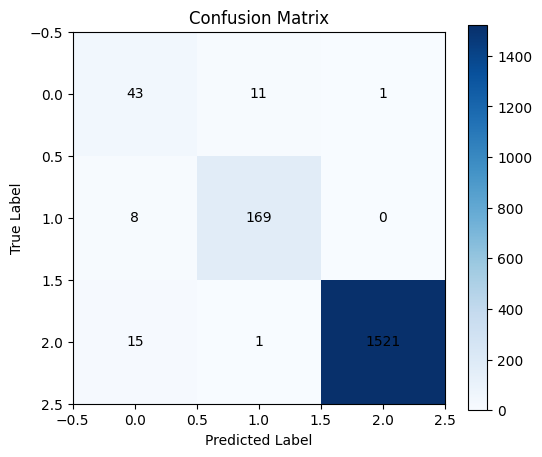

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import numpy as np

# predict class probabilities
y_prob = model.predict(X_test_scaled)

# convert probabilities to predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# macro f1-score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("\nMacro F1-score:", round(macro_f1, 4))

# precision / recall / f1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.show()

In [ ]:
#TASK 3
# Activation function 1: ReLU
tf.random.set_seed(42)
model_relu = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_relu.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4782 - loss: 1.2729 - val_accuracy: 0.6544 - val_loss: 0.9658 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7162 - loss: 0.9436 - val_accuracy: 0.7534 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7768 - loss: 0.8584 - val_accuracy: 0.7647 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8020 - loss: 0.7938 - val_accuracy: 0.7986 - val_loss: 0.6187 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8233 - loss: 0.7555 - val_accuracy: 0.8241 - val_loss: 0.5609 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8404 - loss: 0.7000 - val_accuracy: 0.8331 - val_loss: 0.5396 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8451 - loss: 0.6929 - v

In [ ]:
# Activation function 2: ELU
tf.random.set_seed(42)
model_elu = Sequential([
    Dense(128, activation='elu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='elu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='elu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_elu.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_elu = model_elu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5253 - loss: 1.3434 - val_accuracy: 0.7087 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7158 - loss: 0.9983 - val_accuracy: 0.7540 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7608 - loss: 0.8970 - val_accuracy: 0.7777 - val_loss: 0.6595 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7912 - loss: 0.8338 - val_accuracy: 0.8167 - val_loss: 0.5917 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8021 - loss: 0.8154 - val_accuracy: 0.8133 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8186 - loss: 0.7810 - val_accuracy: 0.8292 - val_loss: 0.5418 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8213 - loss: 0.7723 - v

In [ ]:
# Activation function 3: Swish
tf.random.set_seed(42)
model_swish = Sequential([
    Dense(128, activation='swish', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='swish', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='swish', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_swish.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_swish = model_swish.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5002 - loss: 1.2353 - val_accuracy: 0.6640 - val_loss: 0.8810 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7266 - loss: 0.9361 - val_accuracy: 0.7330 - val_loss: 0.7175 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7825 - loss: 0.8311 - val_accuracy: 0.7919 - val_loss: 0.6215 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.7663 - val_accuracy: 0.8071 - val_loss: 0.5425 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8243 - loss: 0.7585 - val_accuracy: 0.8156 - val_loss: 0.5367 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.7016 - val_accuracy: 0.8343 - val_loss: 0.5124 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8434 - loss: 0.6783 - v

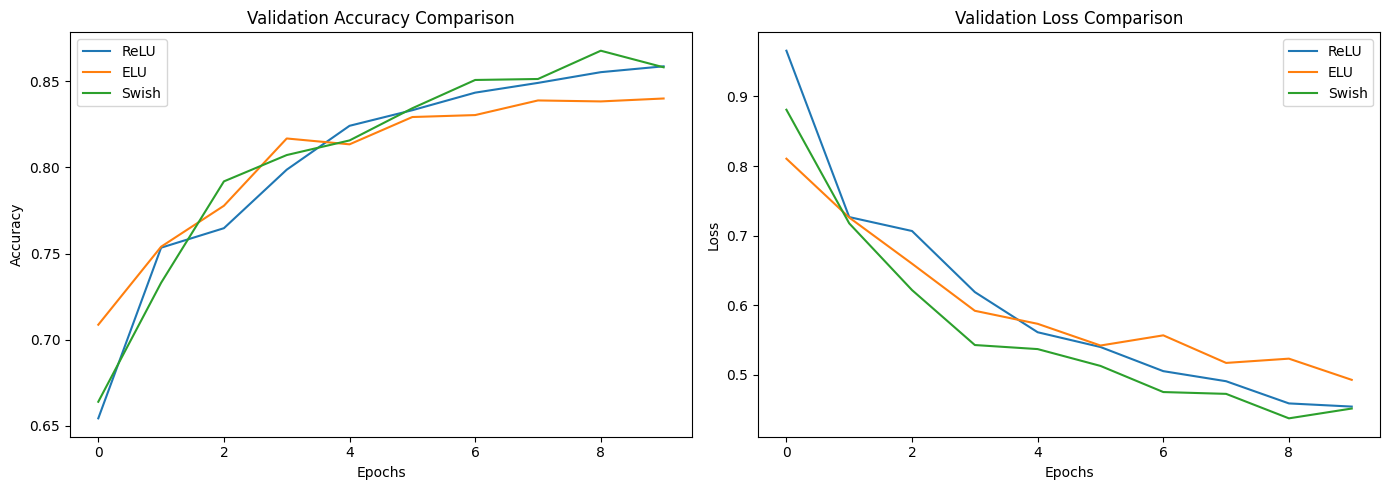

In [ ]:
# ================= Activation Function Comparison Plot =================
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Validation Accuracy Comparison
plt.subplot(1,2,1)
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_elu.history['val_accuracy'], label='ELU')
plt.plot(history_swish.history['val_accuracy'], label='Swish')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss Comparison
plt.subplot(1,2,2)
plt.plot(history_relu.history['val_loss'], label='ReLU')
plt.plot(history_elu.history['val_loss'], label='ELU')
plt.plot(history_swish.history['val_loss'], label='Swish')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ================= Final Performance Results =================
acc_relu = max(history_relu.history['val_accuracy'])
acc_elu = max(history_elu.history['val_accuracy'])
acc_swish = max(history_swish.history['val_accuracy'])

loss_relu = min(history_relu.history['val_loss'])
loss_elu = min(history_elu.history['val_loss'])
loss_swish = min(history_swish.history['val_loss'])

print("===== Activation Function Comparison Results =====")
print(f"ReLU   Best Accuracy: {acc_relu:.4f} | Minimum Loss: {loss_relu:.4f}")
print(f"ELU    Best Accuracy: {acc_elu:.4f} | Minimum Loss: {loss_elu:.4f}")
print(f"Swish  Best Accuracy: {acc_swish:.4f} | Minimum Loss: {loss_swish:.4f}")

===== Activation Function Comparison Results =====
ReLU   Best Accuracy: 0.8586 | Minimum Loss: 0.4540
ELU    Best Accuracy: 0.8399 | Minimum Loss: 0.4924
Swish  Best Accuracy: 0.8676 | Minimum Loss: 0.4370



==================================================  Fold 1/5  ==================================================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 completed - Validation Accuracy: 0.9576

==================================================  Fold 2/5  ==================================================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 completed - Validation Accuracy: 0.9341

==================================================  Fold 3/5  ==================================================


...

Fold 3 completed - Validation Accuracy: 0.9651

==================================================  Fold 4/5  ==================================================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 completed - Validation Accuracy: 0.9696

==================================================  Fold 5/5  ==================================================


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 completed - Validation Accuracy: 0.9526

5-Fold 平均准确率: 0.9558 (+/- 0.0123)
Macro F1  :  0.8084 ± 0.0325
RMSE      :  0.3528 ± 0.0514
MAE       :  0.0719 ± 0.0209


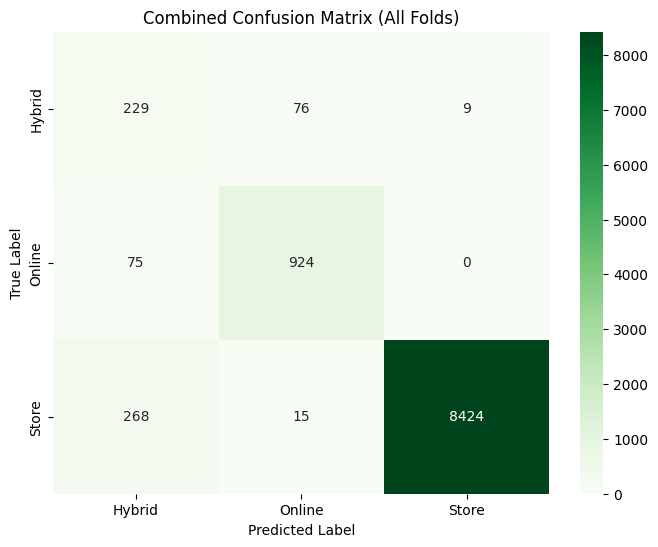

In [ ]:
# =========================
# Task 4: K-Fold Cross-Validation
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns

# Hybrid → 0 | Online → 1 | Store → 2
X_kfold = np.vstack([X_train.values, X_val.values])
y_kfold = np.concatenate([y_train.values, y_val.values])

class_weight = {0: 10.66, 1: 3.34, 2: 0.38}

def build_model(input_dim):
    tf.random.set_seed(42)
    m = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.30),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.20),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_histories    = []
fold_metrics      = []
all_fold_accuracies = []
all_y_true        = []
all_y_pred        = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_kfold, y_kfold), 1):
    print(f"\n{'='*50}  Fold {fold}/{N_SPLITS}  {'='*50}")

    X_tr, X_va = X_kfold[train_idx], X_kfold[val_idx]
    y_tr, y_va = y_kfold[train_idx], y_kfold[val_idx]

    scaler_fold = StandardScaler()
    X_tr_s = scaler_fold.fit_transform(X_tr)
    X_va_s = scaler_fold.transform(X_va)

    fold_model = build_model(X_tr_s.shape[1])

    cb_es = EarlyStopping(monitor='val_loss', patience=5,
                          restore_best_weights=True, verbose=0)
    cb_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=3, min_lr=1e-6, verbose=0)

    hist = fold_model.fit(
        X_tr_s, y_tr,
        validation_data=(X_va_s, y_va),
        epochs=50,
        batch_size=64,
        class_weight=class_weight,
        callbacks=[cb_es, cb_lr],
        verbose=0
    )
    fold_histories.append(hist.history)

    y_pred_fold = np.argmax(fold_model.predict(X_va_s, verbose=0), axis=1)

    # Accuracy per fold
    acc  = accuracy_score(y_va, y_pred_fold)
    f1   = f1_score(y_va, y_pred_fold, average='macro')
    rmse = np.sqrt(mean_squared_error(y_va, y_pred_fold))
    mae  = mean_absolute_error(y_va, y_pred_fold)

    fold_metrics.append((f1, rmse, mae))
    all_fold_accuracies.append(acc)

    # Collect predictions for the final combined confusion matrix
    all_y_true.extend(y_va)
    all_y_pred.extend(y_pred_fold)

    print(f"Fold {fold} completed - Validation Accuracy: {acc:.4f}")

# 3. Print final evaluation report
print("\n" + "="*30)
print(f"5-Fold 平均准确率: {np.mean(all_fold_accuracies):.4f} (+/- {np.std(all_fold_accuracies):.4f})")
print(f"Macro F1  :  {np.mean([m[0] for m in fold_metrics]):.4f} ± {np.std([m[0] for m in fold_metrics]):.4f}")
print(f"RMSE      :  {np.mean([m[1] for m in fold_metrics]):.4f} ± {np.std([m[1] for m in fold_metrics]):.4f}")
print(f"MAE       :  {np.mean([m[2] for m in fold_metrics]):.4f} ± {np.std([m[2] for m in fold_metrics]):.4f}")
print("="*30)

# 4. Plot combined confusion matrix (label order: 0=Hybrid, 1=Online, 2=Store)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Hybrid', 'Online', 'Store'],
            yticklabels=['Hybrid', 'Online', 'Store'])
plt.title('Combined Confusion Matrix (All Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print("\nClassification Report (All Folds Combined):")
print("                    Predicted Label")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=['Hybrid', 'Online', 'Store'],
    digits=2
))


Classification Report (All Folds Combined):
                    Predicted Label
              precision    recall  f1-score   support

      Hybrid       0.40      0.73      0.52       314
      Online       0.91      0.92      0.92       999
       Store       1.00      0.97      0.98      8707

    accuracy                           0.96     10020
   macro avg       0.77      0.87      0.81     10020
weighted avg       0.97      0.96      0.96     10020



In [ ]:
# 建立 ethical analysis 用的数据表
ethics_df = X_test.copy().reset_index(drop=True)
ethics_df["y_true"] = pd.Series(y_test).reset_index(drop=True)
ethics_df["y_pred"] = pd.Series(y_pred).reset_index(drop=True)

ethics_df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3,y_true,y_pred
0,42,100637,5.1,4,5.3,3,7,44,18,26016,...,9,1,8,6,True,False,False,False,2,2
1,65,167402,7.9,14,3.5,4,5,16,13,136218,...,5,7,10,8,False,False,False,False,2,2
2,51,54950,3.1,6,1.5,5,9,39,18,118098,...,8,6,9,6,True,False,False,True,2,2
3,26,123621,2.6,3,2.6,3,5,24,5,145807,...,2,5,6,7,False,False,False,True,1,1
4,63,109279,5.5,11,2.5,4,6,40,15,70212,...,5,4,8,7,False,True,True,False,2,2


In [ ]:
gender_dummy_cols = [c for c in ethics_df.columns if c.startswith("gender_")]
print(gender_dummy_cols)

if len(gender_dummy_cols) > 0:
    raw_gender_values = sorted(df["gender"].dropna().astype(str).unique())
    kept_gender_values = [c.replace("gender_", "") for c in gender_dummy_cols]
    base_gender = [g for g in raw_gender_values if g not in kept_gender_values][0]

    def get_gender_group(row):
        for c in gender_dummy_cols:
            if row[c] == 1:
                return c.replace("gender_", "")
        return base_gender

    ethics_df["gender_group"] = ethics_df.apply(get_gender_group, axis=1)

ethics_df[["gender_group"]].head()

['gender_Male', 'gender_Other', 'gender_group']


,gender_group
0,Male
1,Female
2,Male
3,Female
4,Other


In [ ]:
#city tier分组
city_dummy_cols = [c for c in ethics_df.columns if c.startswith("city_tier_")]
print(city_dummy_cols)

if len(city_dummy_cols) > 0:
    raw_city_values = sorted(df["city_tier"].dropna().astype(str).unique())
    kept_city_values = [c.replace("city_tier_", "") for c in city_dummy_cols]
    base_city = [g for g in raw_city_values if g not in kept_city_values][0]

    def get_city_group(row):
        for c in city_dummy_cols:
            if row[c] == 1:
                return c.replace("city_tier_", "")
        return base_city

    ethics_df["city_group"] = ethics_df.apply(get_city_group, axis=1)

ethics_df[["city_group"]].head()

['city_tier_Tier 2', 'city_tier_Tier 3']


,city_group
0,Tier 1
1,Tier 1
2,Tier 3
3,Tier 3
4,Tier 2


In [ ]:
#age, income分组
if "age" in ethics_df.columns:
    ethics_df["age_group"] = pd.cut(
        ethics_df["age"],
        bins=[0, 25, 40, 60, 120],
        labels=["18-25", "26-40", "41-60", "60+"],
        include_lowest=True
    )

if "monthly_income" in ethics_df.columns:
    ethics_df["income_group"] = pd.qcut(
        ethics_df["monthly_income"],
        q=4,
        labels=["Low", "Mid-Low", "Mid-High", "High"],
        duplicates="drop"
    )

ethics_df[["age", "age_group", "monthly_income", "income_group"]].head()

,age,age_group,monthly_income,income_group
0,42,41-60,100637,Mid-Low
1,65,60+,167402,Mid-High
2,51,41-60,54950,Low
3,26,26-40,123621,Mid-Low
4,63,60+,109279,Mid-Low


In [ ]:
#定义评价函数
ALL_LABELS = sorted(ethics_df["y_true"].unique())

def subgroup_metrics(df_in, group_col):
    rows = []

    for group, subdf in df_in.groupby(group_col, dropna=False):
        rows.append({
            "group": group,
            "n": len(subdf),
            "accuracy": round(accuracy_score(subdf["y_true"], subdf["y_pred"]), 4),
            "macro_f1": round(
                f1_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "precision_macro": round(
                precision_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "recall_macro": round(
                recall_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "error_rate": round((subdf["y_true"] != subdf["y_pred"]).mean(), 4)
        })

    return pd.DataFrame(rows).sort_values(by="n", ascending=False).reset_index(drop=True)

In [ ]:
#gender result
gender_results = subgroup_metrics(ethics_df, "gender_group")
print("Gender subgroup performance ")
display(gender_results)
#age result
age_results = subgroup_metrics(ethics_df, "age_group")
print("Age subgroup performance")
display(age_results)
#city tier result
city_results = subgroup_metrics(ethics_df, "city_group")
print("City-tier subgroup performance")
display(city_results)
#income result
income_results = subgroup_metrics(ethics_df, "income_group")
print("Income subgroup performance")
display(income_results)

Gender subgroup performance 


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Male,620,0.9823,0.8530,0.8343,0.8744,0.0177
1,Female,589,0.9796,0.8855,0.8797,0.8917,0.0204
2,Other,560,0.9768,0.8967,0.8652,0.9442,0.0232


Age subgroup performance


/tmp/ipykernel_2694/1436359269.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, subdf in df_in.groupby(group_col, dropna=False):


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,41-60,577,0.9809,0.8886,0.8828,0.8959,0.0191
1,60+,540,0.9759,0.8675,0.8280,0.9445,0.0241
2,26-40,423,0.9811,0.8918,0.8804,0.9055,0.0189
3,18-25,229,0.9825,0.8879,0.8758,0.9014,0.0175


City-tier subgroup performance


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Tier 1,615,0.9724,0.8642,0.8396,0.8974,0.0276
1,Tier 3,610,0.9836,0.8803,0.8605,0.9023,0.0164
2,Tier 2,544,0.9835,0.9088,0.8941,0.9251,0.0165


/tmp/ipykernel_2694/1436359269.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, subdf in df_in.groupby(group_col, dropna=False):


Income subgroup performance


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Low,443,0.9774,0.8727,0.8626,0.8846,0.0226
1,Mid-Low,442,0.9842,0.8936,0.8734,0.9200,0.0158
2,Mid-High,442,0.9864,0.9268,0.8984,0.9638,0.0136
3,High,442,0.9706,0.8410,0.8125,0.8740,0.0294


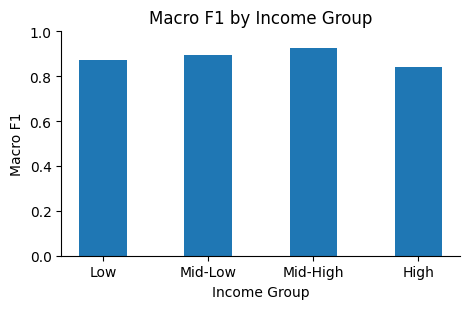

In [ ]:
#income subgroup 柱状图
import matplotlib.pyplot as plt

plt.figure(figsize=(4.8, 3.2))
plt.bar(
    income_results["group"].astype(str),
    income_results["macro_f1"],
    width=0.45
)

plt.title("Macro F1 by Income Group", fontsize=12)
plt.xlabel("Income Group", fontsize=10)
plt.ylabel("Macro F1", fontsize=10)
plt.ylim(0, 1)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

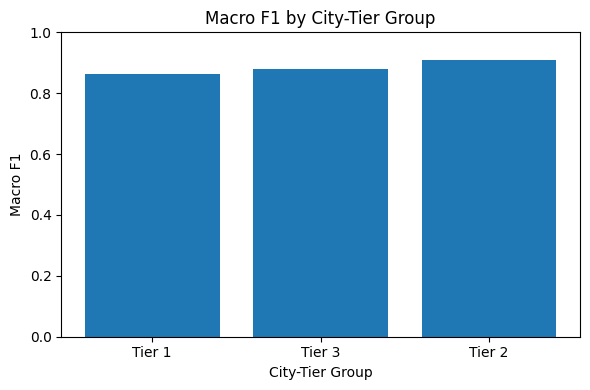

In [ ]:
#city tier柱状图
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(city_results["group"].astype(str), city_results["macro_f1"])
plt.title("Macro F1 by City-Tier Group")
plt.xlabel("City-Tier Group")
plt.ylabel("Macro F1")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

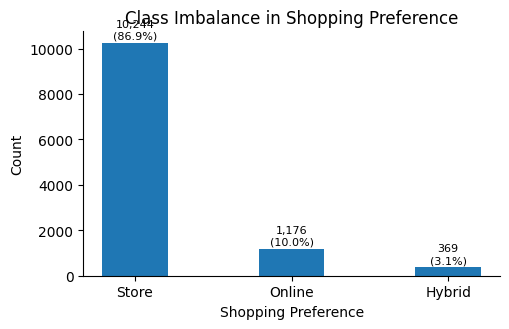

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["shopping_preference"].value_counts()
class_pct = class_counts / class_counts.sum() * 100

plt.figure(figsize=(5.2, 3.4))
bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values,
    width=0.42
)

plt.title("Class Imbalance in Shopping Preference", fontsize=12)
plt.xlabel("Shopping Preference", fontsize=10)
plt.ylabel("Count", fontsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + class_counts.max()*0.01,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()